# 逻辑回归-总结果

In [2]:
import pandas as pd
df1 = pd.read_csv('E:\\论文\\第二篇论文\\截止到2023年2月数据汇总\\结构化数据.csv',encoding = 'utf-8-sig')
df1 = df1.dropna()

In [3]:
# 这里我希望将neutral作为对照组，因此sentiment_type变动如下
# neutral  negative postive
list_sentiment = list(df1['Sentiment'])
list_sentiment_type = []
for i in list_sentiment:
    if i == 'positive':
        list_sentiment_type.append(1)
    elif i == 'negative':
        list_sentiment_type.append(0)
    else:
        list_sentiment_type.append(2)
df1['sentiment_type'] = list_sentiment_type

In [4]:
import numpy as np
df2 = df1.set_index(['comment_time','scence_id'])


In [5]:
# # 创建指标
# # 1 生成移动平均线指标
df2['MA2_sentiment_score'] = df2['sentiment_score'].rolling(2).mean()
df2['MA3_sentiment_score'] = df2['sentiment_score'].rolling(3).mean()
# df2['MA5_sentiment_score'] = df2['sentiment_score'].rolling(5).mean()
# df2['MA7_sentiment_score'] = df2['sentiment_score'].rolling(7).mean()
# df2['MA10_sentiment_score'] = df2['sentiment_score'].rolling(10).mean()
# # df2['MA10_sentiment_score'] = df2['sentiment_score'].rolling(10).mean()
df2["previous_sentiment_score"] =df2["sentiment_score"].shift(1)
df2["previous_sentiment_score2"] =df2["sentiment_score"].shift(2)
df2

df2 = df2.dropna()

In [16]:
# 划分X和y
import numpy as np
# X = df2[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point']]
X = df2[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2','MA2_sentiment_score','MA3_sentiment_score']]
# X = df2[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2']]
# X = df2[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score']]

y = np.array(df2['sentiment_type']).astype('int')

In [17]:
from statsmodels.discrete.discrete_model import MNLogit
model_LR = MNLogit(y,X,missing='drop').fit()
model_LR.summary()	# 查看结果
model_LR.params		# 查看参数的系数

         Current function value: 0.400186
         Iterations: 35


D:\python\lib\site-packages\statsmodels\base\model.py:606: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
D:\python\lib\site-packages\statsmodels\discrete\discrete_model.py:4247: RuntimeWarning: invalid value encountered in sqrt
  bse = np.sqrt(np.diag(self.cov_params()))


,0,1
outbreak,-5.361457,-2.475561
temperature_1,-11.233486,-4.546529
holiday,-0.502704,-0.126206
period,0.488105,0.250308
month,-0.393281,-0.170905
weather_point,-0.650649,-0.257031
previous_sentiment_score,-37.113734,-20.508298
previous_sentiment_score2,-12.052946,-6.434998
MA2_sentiment_score,50.103380,28.302154
MA3_sentiment_score,29.384642,16.723147


In [18]:
# 第三类相当于是对照组，n分类的只会输出n-1个结果

In [19]:
#  查看模型结果
model_LR.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                    Results: MNLogit
========================================================================================
Model:                      MNLogit                 Pseudo R-squared:        0.609      
Dependent Variable:         y                       AIC:                     252103.6303
Date:                       2023-04-15 22:21        BIC:                     252316.8326
No. Observations:           314933                  Log-Likelihood:          -1.2603e+05
Df Model:                   18                      LL-Null:                 -3.2205e+05
Df Residuals:               314913                  LLR p-value:             0.0000     
Converged:                  0.0000                  Scale:                   1.0000     
No. Iterations:             35.0000                                                     
----------------------------------------------------------------------------------------
          y = 0            Coef.     Std.Err.      t     P>|t|     [0.025       0.975]  
----------------------------------------------------------------------------------------
                 outbreak  -5.3615      0.0600  -89.4000 0.0000      -5.4790     -5.2439
            temperature_1 -11.2335      0.0712 -157.7960 0.0000     -11.3730    -11.0940
                  holiday  -0.5027      0.0293  -17.1462 0.0000      -0.5602     -0.4452
                   period   0.4881      0.0115   42.5387 0.0000       0.4656      0.5106
                    month  -0.3933      0.0043  -92.5015 0.0000      -0.4016     -0.3849
            weather_point  -0.6506      0.0868   -7.4961 0.0000      -0.8208     -0.4805
 previous_sentiment_score -37.1137      0.1313 -282.7584 0.0000     -37.3710    -36.8565
previous_sentiment_score2 -12.0529  53532.4285   -0.0002 0.9998 -104933.6848 104909.5789
      MA2_sentiment_score  50.1034 107422.6914    0.0005 0.9996 -210494.5029 210594.7097
      MA3_sentiment_score  29.3846 159396.8148    0.0002 0.9999 -312382.6317 312441.4010
----------------------------------------------------------------------------------------
            y = 1               Coef.    Std.Err.      t      P>|t|    [0.025    0.975] 
----------------------------------------------------------------------------------------
                 outbreak       -2.4756    0.0499   -49.5893  0.0000   -2.5734   -2.3777
            temperature_1       -4.5465    0.0585   -77.7842  0.0000   -4.6611   -4.4320
                  holiday       -0.1262    0.0242    -5.2192  0.0000   -0.1736   -0.0788
                   period        0.2503    0.0093    26.9554  0.0000    0.2321    0.2685
                    month       -0.1709    0.0036   -47.1105  0.0000   -0.1780   -0.1638
            weather_point       -0.2570    0.0703    -3.6557  0.0003   -0.3948   -0.1192
 previous_sentiment_score      -20.5083    0.1111  -184.6666  0.0000  -20.7260  -20.2906
previous_sentiment_score2       -6.4350       nan        nan     nan       nan       nan
      MA2_sentiment_score       28.3022       nan        nan     nan       nan       nan
      MA3_sentiment_score       16.7231       nan        nan     nan       nan       nan
========================================================================================

"""

## 逻辑回归模型结果
1. 表1中LLR p-value:	5.9914e-31，说明模型显著
2. 第二张表为相关变量的系数以及t值。显著的有outbreak period month weather_point

In [20]:
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, f1_score, auc
from sklearn.preprocessing import label_binarize 
from itertools import cycle

# Precision Recall 和 F1
nb_classes = 3          # 设置分类数

y_pred = model_LR.predict()      # 自我预测，得到预测为各类的概率
y_pred_max = [np.argmax(y) for y in y_pred]   # 取出y中元素最大值所对应的索引
y_true = y

y_pred_b = label_binarize(y_pred_max, classes=[i for i in range(nb_classes)])    # binarize the output
y_true_b = label_binarize(y_true, classes=[i for i in range(nb_classes)])    # binarize the output

precision = precision_score(y_true_b, y_pred_b, average='micro')
recall = recall_score(y_true_b, y_pred_b, average='micro')
f1_score = f1_score(y_true_b, y_pred_b, average='micro')

print("Precision_score:",precision)
print("Recall_score:",recall)
print("F1_score:",f1_score)

Precision_score: 0.8319928365715883
Recall_score: 0.8319928365715883
F1_score: 0.8319928365715883


## ROC曲线和AUC

D:\python\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\python\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


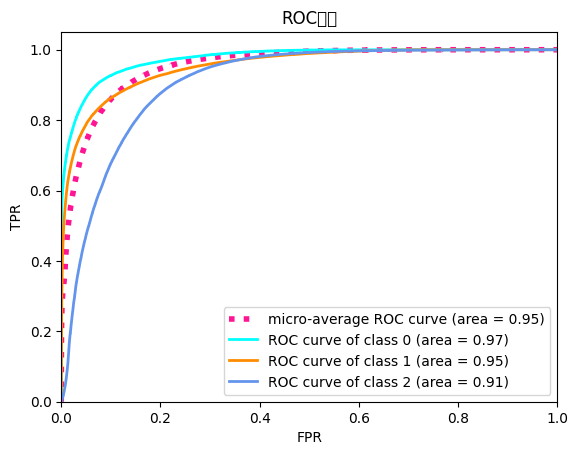

In [21]:
import matplotlib.pyplot as plt

Y_valid = y_true_b
Y_pred = model_LR.predict()  # 用预测的概率值，不然ROC是折线的形式

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(nb_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_valid[:, i], Y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(Y_valid.ravel(), Y_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

lw = 2
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
  label='micro-average ROC curve (area = {0:0.2f})'
  ''.format(roc_auc["micro"]),
  color='deeppink', linestyle=':', linewidth=4)


colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])  # 几个类别就设置几个颜色
for i, color in zip(range(nb_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
    label='ROC curve of class {0} (area = {1:0.2f})'
    ''.format(i, roc_auc[i]))

# plt.plot([0, 1], [0, 1], 'k--', lw=lw)    # 斜着的分界线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC曲线')
plt.legend(loc="lower right")
# plt.savefig("../images/ROC/ROC_3分类.png")
plt.show()


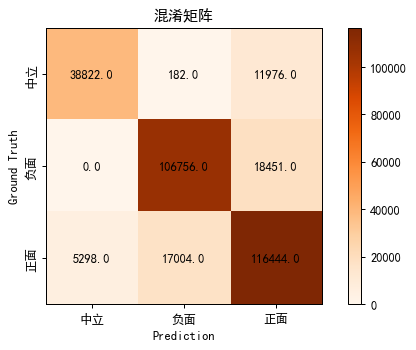

In [22]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['font.family']='sans-serif'  # 解决绘图中文乱码
plt.rcParams['axes.unicode_minus'] = False   # 解决负号显示为框

# 混淆矩阵
classes = ['中立','负面','正面']

confusion_matrix = model_LR.pred_table()

plt.figure(figsize=(6, 4), dpi=90)

plt.imshow(confusion_matrix, interpolation='nearest', cmap=plt.cm.Oranges)  #按照像素显示出矩阵
plt.title('混淆矩阵')
plt.colorbar()

tick_marks = np.arange(3)
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes, rotation=90,verticalalignment='center')

for x in range(len(confusion_matrix)):
    for y in range(len(confusion_matrix)):
        plt.annotate(confusion_matrix[y,x], xy = (x,y), horizontalalignment = 'center', verticalalignment = 'center')

plt.ylabel('Ground Truth')
plt.xlabel('Prediction')
plt.tight_layout()


# 看不同period的逻辑回归结果

In [23]:
df2['period'].value_counts()

5    111805
4    109034
2     29456
0     27738
3     26675
6      6043
1      4182
Name: period, dtype: int64

In [25]:
df_period_0 = df2[df2['period']==0]
df_period_1 = df2[df2['period']==1]
df_period_2 = df2[df2['period']==2]
df_period_3 = df2[df2['period']==3]
df_period_4 = df2[df2['period']==4]
df_period_5 =  df2[df2['period']==5]
df_period_6 =  df2[df2['period']==6]
# df_period_0

## period_0的逻辑回归

In [27]:
# 划分X和y
import numpy as np
# X = df_period_0[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point']]
X = df_period_0[['temperature_1', 'holiday', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2','MA2_sentiment_score','MA3_sentiment_score']]
# X = df_period_0[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2']]
# X = df_period_0[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score']]

y = np.array(df_period_0['sentiment_type']).astype('int')

# 模型结果查看
from statsmodels.discrete.discrete_model import MNLogit
model_LR = MNLogit(y,X,missing='drop').fit()
model_LR.summary()	# 查看结果
model_LR.params		# 查看参数的系数


         Current function value: 0.407601
         Iterations: 35


D:\python\lib\site-packages\statsmodels\base\model.py:606: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)


,0,1
temperature_1,-13.278771,-5.955927
holiday,0.205281,0.137219
month,-0.607057,-0.280792
weather_point,-2.375220,-1.116516
previous_sentiment_score,-37.373565,-21.490207
previous_sentiment_score2,-11.805060,-6.495756
MA2_sentiment_score,50.891121,29.919010
MA3_sentiment_score,29.992378,17.780766


In [28]:
#  查看模型结果
model_LR.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                     Results: MNLogit
==========================================================================================
Model:                       MNLogit                  Pseudo R-squared:         0.598     
Dependent Variable:          y                        AIC:                      22644.0863
Date:                        2023-04-15 22:23         BIC:                      22775.7752
No. Observations:            27738                    Log-Likelihood:           -11306.   
Df Model:                    14                       LL-Null:                  -28133.   
Df Residuals:                27722                    LLR p-value:              0.0000    
Converged:                   0.0000                   Scale:                    1.0000    
No. Iterations:              35.0000                                                      
------------------------------------------------------------------------------------------
          y = 0            Coef.     Std.Err.      t     P>|t|      [0.025       0.975]   
------------------------------------------------------------------------------------------
            temperature_1 -13.2788       0.2357 -56.3397 0.0000      -13.7407     -12.8168
                  holiday   0.2053       0.1029   1.9953 0.0460        0.0036       0.4069
                    month  -0.6071       0.0158 -38.4203 0.0000       -0.6380      -0.5761
            weather_point  -2.3752       0.2896  -8.2019 0.0000       -2.9428      -1.8076
 previous_sentiment_score -37.3736       0.4545 -82.2254 0.0000      -38.2644     -36.4827
previous_sentiment_score2 -11.8051  440545.0272  -0.0000 1.0000  -863464.1920  863440.5819
      MA2_sentiment_score  50.8911  881020.3418   0.0001 1.0000 -1726717.2485 1726819.0308
      MA3_sentiment_score  29.9924 1321563.0068   0.0000 1.0000 -2590185.9043 2590245.8891
------------------------------------------------------------------------------------------
          y = 1             Coef.     Std.Err.     t     P>|t|      [0.025       0.975]   
------------------------------------------------------------------------------------------
            temperature_1   -5.9559      0.1980 -30.0802 0.0000       -6.3440      -5.5679
                  holiday    0.1372      0.0865   1.5864 0.1126       -0.0323       0.3067
                    month   -0.2808      0.0137 -20.4422 0.0000       -0.3077      -0.2539
            weather_point   -1.1165      0.2368  -4.7144 0.0000       -1.5807      -0.6523
 previous_sentiment_score  -21.4902      0.3935 -54.6104 0.0000      -22.2615     -20.7189
previous_sentiment_score2   -6.4958 316078.7095  -0.0000 1.0000  -619509.3826  619496.3911
      MA2_sentiment_score   29.9190 632157.4189   0.0000 1.0000 -1238975.8547 1239035.6927
      MA3_sentiment_score   17.7808 948236.1284   0.0000 1.0000 -1858490.8797 1858526.4413
==========================================================================================

"""

In [29]:
# 逻辑回归模型评价
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, f1_score, auc
from sklearn.preprocessing import label_binarize 
from itertools import cycle

# Precision Recall 和 F1
nb_classes = 3          # 设置分类数

y_pred = model_LR.predict()      # 自我预测，得到预测为各类的概率
y_pred_max = [np.argmax(y) for y in y_pred]   # 取出y中元素最大值所对应的索引
y_true = y

y_pred_b = label_binarize(y_pred_max, classes=[i for i in range(nb_classes)])    # binarize the output
y_true_b = label_binarize(y_true, classes=[i for i in range(nb_classes)])    # binarize the output

precision = precision_score(y_true_b, y_pred_b, average='micro')
recall = recall_score(y_true_b, y_pred_b, average='micro')
f1_score = f1_score(y_true_b, y_pred_b, average='micro')

print("Precision_score:",precision)
print("Recall_score:",recall)
print("F1_score:",f1_score)

Precision_score: 0.836577979666883
Recall_score: 0.836577979666883
F1_score: 0.836577979666883


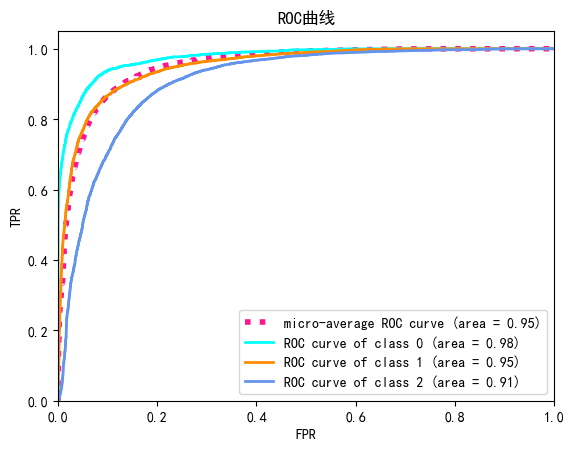

In [30]:

# ROC与AUC
import matplotlib.pyplot as plt

Y_valid = y_true_b
Y_pred = model_LR.predict()  # 用预测的概率值，不然ROC是折线的形式

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(nb_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_valid[:, i], Y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(Y_valid.ravel(), Y_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

lw = 2
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
  label='micro-average ROC curve (area = {0:0.2f})'
  ''.format(roc_auc["micro"]),
  color='deeppink', linestyle=':', linewidth=4)


colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])  # 几个类别就设置几个颜色
for i, color in zip(range(nb_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
    label='ROC curve of class {0} (area = {1:0.2f})'
    ''.format(i, roc_auc[i]))

# plt.plot([0, 1], [0, 1], 'k--', lw=lw)    # 斜着的分界线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC曲线')
plt.legend(loc="lower right")
# plt.savefig("../images/ROC/ROC_3分类.png")
plt.show()

# period_1

In [31]:
# 划分X和y
import numpy as np
# X = df_period_1[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point']]
X = df_period_1[['temperature_1', 'holiday', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2','MA2_sentiment_score','MA3_sentiment_score']]
# X = df_period_1[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2']]
# X = df_period_1[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score']]

y = np.array(df_period_1['sentiment_type']).astype('int')


from statsmodels.discrete.discrete_model import MNLogit
model_LR = MNLogit(y,X,missing='drop').fit()
model_LR.summary()	# 查看结果
model_LR.params		# 查看参数的系数

         Current function value: 0.443591
         Iterations: 35


D:\python\lib\site-packages\statsmodels\base\model.py:606: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
D:\python\lib\site-packages\statsmodels\discrete\discrete_model.py:4247: RuntimeWarning: invalid value encountered in sqrt
  bse = np.sqrt(np.diag(self.cov_params()))


,0,1
temperature_1,-19.659249,-7.660094
holiday,-1.739322,-0.651594
month,-0.198984,-0.069509
weather_point,-1.387627,-0.689398
previous_sentiment_score,-34.107048,-18.152149
previous_sentiment_score2,-10.654662,-5.616311
MA2_sentiment_score,45.097600,24.513875
MA3_sentiment_score,26.513510,14.470479


In [32]:
#  查看模型结果
model_LR.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                     Results: MNLogit
==========================================================================================
Model:                        MNLogit                  Pseudo R-squared:         0.575    
Dependent Variable:           y                        AIC:                      3742.1939
Date:                         2023-04-15 22:25         BIC:                      3843.6106
No. Observations:             4182                     Log-Likelihood:           -1855.1  
Df Model:                     14                       LL-Null:                  -4368.6  
Df Residuals:                 4166                     LLR p-value:              0.0000   
Converged:                    0.0000                   Scale:                    1.0000   
No. Iterations:               35.0000                                                     
------------------------------------------------------------------------------------------
          y = 0               Coef.     Std.Err.      t       P>|t|     [0.025     0.975] 
------------------------------------------------------------------------------------------
            temperature_1    -19.6592     0.8496   -23.1400   0.0000   -21.3244   -17.9941
                  holiday     -1.7393     0.2208    -7.8791   0.0000    -2.1720    -1.3067
                    month     -0.1990     0.1037    -1.9184   0.0551    -0.4023     0.0043
            weather_point     -1.3876     0.8555    -1.6219   0.1048    -3.0645     0.2892
 previous_sentiment_score    -34.1070     1.0229   -33.3440   0.0000   -36.1119   -32.1022
previous_sentiment_score2    -10.6547        nan        nan      nan        nan        nan
      MA2_sentiment_score     45.0976        nan        nan      nan        nan        nan
      MA3_sentiment_score     26.5135        nan        nan      nan        nan        nan
------------------------------------------------------------------------------------------
          y = 1            Coef.     Std.Err.      t     P>|t|      [0.025       0.975]   
------------------------------------------------------------------------------------------
            temperature_1  -7.6601       0.6375 -12.0156 0.0000       -8.9096      -6.4106
                  holiday  -0.6516       0.1766  -3.6894 0.0002       -0.9977      -0.3054
                    month  -0.0695       0.0844  -0.8231 0.4105       -0.2350       0.0960
            weather_point  -0.6894       0.6683  -1.0316 0.3023       -1.9992       0.6204
 previous_sentiment_score -18.1521       0.8291 -21.8930 0.0000      -19.7772     -16.5271
previous_sentiment_score2  -5.6163  809596.0516  -0.0000 1.0000 -1586784.7194 1586773.4868
      MA2_sentiment_score  24.5139 1619192.1032   0.0000 1.0000 -3173533.6924 3173582.7201
      MA3_sentiment_score  14.4705 2428788.1547   0.0000 1.0000 -4760322.8389 4760351.7798
==========================================================================================

"""

In [33]:

# 逻辑回归模型评价
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, f1_score, auc
from sklearn.preprocessing import label_binarize 
from itertools import cycle

# Precision Recall 和 F1
nb_classes = 3          # 设置分类数

y_pred = model_LR.predict()      # 自我预测，得到预测为各类的概率
y_pred_max = [np.argmax(y) for y in y_pred]   # 取出y中元素最大值所对应的索引
y_true = y

y_pred_b = label_binarize(y_pred_max, classes=[i for i in range(nb_classes)])    # binarize the output
y_true_b = label_binarize(y_true, classes=[i for i in range(nb_classes)])    # binarize the output

precision = precision_score(y_true_b, y_pred_b, average='micro')
recall = recall_score(y_true_b, y_pred_b, average='micro')
f1_score = f1_score(y_true_b, y_pred_b, average='micro')

print("Precision_score:",precision)
print("Recall_score:",recall)
print("F1_score:",f1_score)


Precision_score: 0.8106169296987088
Recall_score: 0.8106169296987088
F1_score: 0.8106169296987087


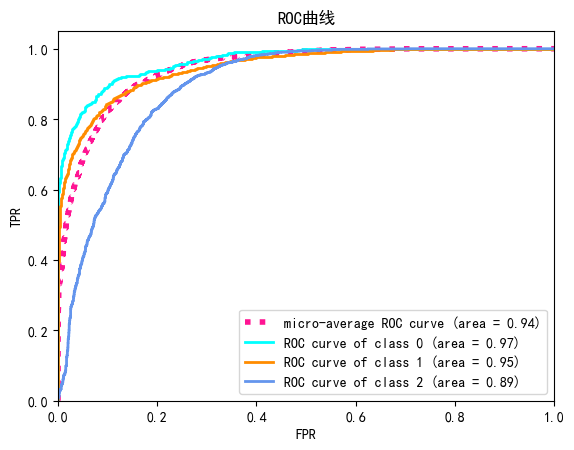

In [34]:

# ROC与AUC
import matplotlib.pyplot as plt

Y_valid = y_true_b
Y_pred = model_LR.predict()  # 用预测的概率值，不然ROC是折线的形式

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(nb_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_valid[:, i], Y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(Y_valid.ravel(), Y_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

lw = 2
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
  label='micro-average ROC curve (area = {0:0.2f})'
  ''.format(roc_auc["micro"]),
  color='deeppink', linestyle=':', linewidth=4)


colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])  # 几个类别就设置几个颜色
for i, color in zip(range(nb_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
    label='ROC curve of class {0} (area = {1:0.2f})'
    ''.format(i, roc_auc[i]))

# plt.plot([0, 1], [0, 1], 'k--', lw=lw)    # 斜着的分界线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC曲线')
plt.legend(loc="lower right")
# plt.savefig("../images/ROC/ROC_3分类.png")
plt.show()

# period_2

In [35]:
# 划分X和y
import numpy as np
# X = df_period_2[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point']]
X = df_period_2[['temperature_1', 'holiday', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2','MA2_sentiment_score','MA3_sentiment_score']]
# X = df_period_2[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2']]
# X = df_period_2[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score']]

y = np.array(df_period_2['sentiment_type']).astype('int')

from statsmodels.discrete.discrete_model import MNLogit
model_LR = MNLogit(y,X,missing='drop').fit()
model_LR.summary()	# 查看结果
model_LR.params		# 查看参数的系数


Optimization terminated successfully.
         Current function value: 0.351241
         Iterations 30


,0,1
temperature_1,-17.882245,-6.686606
holiday,-0.679431,-0.260289
month,-0.739228,-0.294879
weather_point,-0.343163,-0.653175
previous_sentiment_score,-41.192376,-21.321222
previous_sentiment_score2,-12.336499,-6.260690
MA2_sentiment_score,57.618789,30.182439
MA3_sentiment_score,34.300358,18.034726


In [36]:
#  查看模型结果
model_LR.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                      Results: MNLogit
============================================================================================
Model:                       MNLogit                   Pseudo R-squared:          0.659     
Dependent Variable:          y                         AIC:                       20724.2908
Date:                        2023-04-15 22:25          BIC:                       20856.9412
No. Observations:            29456                     Log-Likelihood:            -10346.   
Df Model:                    14                        LL-Null:                   -30364.   
Df Residuals:                29440                     LLR p-value:               0.0000    
Converged:                   1.0000                    Scale:                     1.0000    
No. Iterations:              30.0000                                                        
--------------------------------------------------------------------------------------------
           y = 0             Coef.     Std.Err.      t     P>|t|      [0.025       0.975]   
--------------------------------------------------------------------------------------------
            temperature_1   -17.8822       0.2751 -65.0026 0.0000      -18.4214     -17.3431
                  holiday    -0.6794       0.0931  -7.2987 0.0000       -0.8619      -0.4970
                    month    -0.7392       0.0180 -41.0333 0.0000       -0.7745      -0.7039
            weather_point    -0.3432       0.2427  -1.4142 0.1573       -0.8188       0.1324
 previous_sentiment_score   -41.1924       0.4682 -87.9804 0.0000      -42.1100     -40.2747
previous_sentiment_score2   -12.3365 1476288.2395  -0.0000 1.0000 -2893484.1167 2893459.4437
      MA2_sentiment_score    57.6188 2554096.8364   0.0000 1.0000 -5005880.1936 5005995.4312
      MA3_sentiment_score    34.3004 3612038.3857   0.0000 1.0000 -7079430.8464 7079499.4471
--------------------------------------------------------------------------------------------
          y = 1            Coef.     Std.Err.      t     P>|t|      [0.025         0.975]   
--------------------------------------------------------------------------------------------
            temperature_1  -6.6866       0.2039 -32.7981 0.0000        -7.0862       -6.2870
                  holiday  -0.2603       0.0743  -3.5029 0.0005        -0.4059       -0.1147
                    month  -0.2949       0.0144 -20.4102 0.0000        -0.3232       -0.2666
            weather_point  -0.6532       0.1879  -3.4755 0.0005        -1.0215       -0.2848
 previous_sentiment_score -21.3212       0.3722 -57.2888 0.0000       -22.0507      -20.5918
previous_sentiment_score2  -6.2607 1702731.2243  -0.0000 1.0000  -3337298.1356  3337285.6143
      MA2_sentiment_score  30.1824 3405462.4486   0.0000 1.0000  -6674553.5674  6674613.9323
      MA3_sentiment_score  18.0347 5108193.6728   0.0000 1.0000 -10011857.5901 10011893.6596
============================================================================================

"""

In [37]:

# 逻辑回归模型评价
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, f1_score, auc
from sklearn.preprocessing import label_binarize 
from itertools import cycle

# Precision Recall 和 F1
nb_classes = 3          # 设置分类数

y_pred = model_LR.predict()      # 自我预测，得到预测为各类的概率
y_pred_max = [np.argmax(y) for y in y_pred]   # 取出y中元素最大值所对应的索引
y_true = y

y_pred_b = label_binarize(y_pred_max, classes=[i for i in range(nb_classes)])    # binarize the output
y_true_b = label_binarize(y_true, classes=[i for i in range(nb_classes)])    # binarize the output

precision = precision_score(y_true_b, y_pred_b, average='micro')
recall = recall_score(y_true_b, y_pred_b, average='micro')
f1_score = f1_score(y_true_b, y_pred_b, average='micro')

print("Precision_score:",precision)
print("Recall_score:",recall)
print("F1_score:",f1_score)


Precision_score: 0.8491648560564911
Recall_score: 0.8491648560564911
F1_score: 0.849164856056491


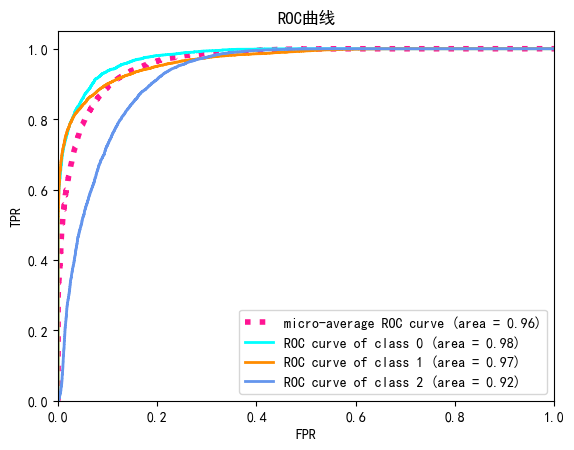

In [38]:
# ROC与AUC
import matplotlib.pyplot as plt

Y_valid = y_true_b
Y_pred = model_LR.predict()  # 用预测的概率值，不然ROC是折线的形式

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(nb_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_valid[:, i], Y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(Y_valid.ravel(), Y_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

lw = 2
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
  label='micro-average ROC curve (area = {0:0.2f})'
  ''.format(roc_auc["micro"]),
  color='deeppink', linestyle=':', linewidth=4)


colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])  # 几个类别就设置几个颜色
for i, color in zip(range(nb_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
    label='ROC curve of class {0} (area = {1:0.2f})'
    ''.format(i, roc_auc[i]))

# plt.plot([0, 1], [0, 1], 'k--', lw=lw)    # 斜着的分界线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC曲线')
plt.legend(loc="lower right")
# plt.savefig("../images/ROC/ROC_3分类.png")
plt.show()


## period_3

In [39]:
# 划分X和y
import numpy as np
# X = df_period_3[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point']]
X = df_period_3[['temperature_1', 'holiday', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2','MA2_sentiment_score','MA3_sentiment_score']]
# X = df_period_3[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2']]
# X = df_period_3[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score']]

y = np.array(df_period_3['sentiment_type']).astype('int')

from statsmodels.discrete.discrete_model import MNLogit
model_LR = MNLogit(y,X,missing='drop').fit()
model_LR.summary()	# 查看结果
model_LR.params		# 查看参数的系数


         Current function value: 0.444716
         Iterations: 35


D:\python\lib\site-packages\statsmodels\base\model.py:606: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
D:\python\lib\site-packages\statsmodels\discrete\discrete_model.py:4247: RuntimeWarning: invalid value encountered in sqrt
  bse = np.sqrt(np.diag(self.cov_params()))


,0,1
temperature_1,-16.218380,-7.283504
holiday,-0.741726,-0.142657
month,-0.267532,-0.124538
weather_point,0.444382,0.472637
previous_sentiment_score,-34.963745,-19.961477
previous_sentiment_score2,-11.874975,-6.536382
MA2_sentiment_score,45.880005,26.989442
MA3_sentiment_score,26.628328,15.814170


In [40]:
#  查看模型结果
model_LR.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                     Results: MNLogit
==========================================================================================
Model:                       MNLogit                  Pseudo R-squared:         0.565     
Dependent Variable:          y                        AIC:                      23757.6246
Date:                        2023-04-15 22:26         BIC:                      23888.6883
No. Observations:            26675                    Log-Likelihood:           -11863.   
Df Model:                    14                       LL-Null:                  -27291.   
Df Residuals:                26659                    LLR p-value:              0.0000    
Converged:                   0.0000                   Scale:                    1.0000    
No. Iterations:              35.0000                                                      
------------------------------------------------------------------------------------------
          y = 0            Coef.     Std.Err.      t     P>|t|      [0.025       0.975]   
------------------------------------------------------------------------------------------
            temperature_1 -16.2184       0.2565 -63.2316 0.0000      -16.7211     -15.7157
                  holiday  -0.7417       0.0845  -8.7743 0.0000       -0.9074      -0.5760
                    month  -0.2675       0.0103 -26.0045 0.0000       -0.2877      -0.2474
            weather_point   0.4444       0.3425   1.2974 0.1945       -0.2269       1.1157
 previous_sentiment_score -34.9637       0.4382 -79.7947 0.0000      -35.8225     -34.1049
previous_sentiment_score2 -11.8750  412701.3935  -0.0000 1.0000  -808891.7426  808867.9927
      MA2_sentiment_score  45.8800  821783.9764   0.0001 1.0000 -1610621.1168 1610712.8768
      MA3_sentiment_score  26.6283 1215434.8922   0.0000 1.0000 -2382181.9859 2382235.2425
------------------------------------------------------------------------------------------
          y = 1               Coef.     Std.Err.      t       P>|t|     [0.025     0.975] 
------------------------------------------------------------------------------------------
            temperature_1     -7.2835     0.2100   -34.6774   0.0000    -7.6952    -6.8718
                  holiday     -0.1427     0.0709    -2.0110   0.0443    -0.2817    -0.0036
                    month     -0.1245     0.0087   -14.2456   0.0000    -0.1417    -0.1074
            weather_point      0.4726     0.2819     1.6768   0.0936    -0.0798     1.0251
 previous_sentiment_score    -19.9615     0.3810   -52.3928   0.0000   -20.7082   -19.2147
previous_sentiment_score2     -6.5364        nan        nan      nan        nan        nan
      MA2_sentiment_score     26.9894        nan        nan      nan        nan        nan
      MA3_sentiment_score     15.8142        nan        nan      nan        nan        nan
==========================================================================================

"""

In [41]:

# 逻辑回归模型评价
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, f1_score, auc
from sklearn.preprocessing import label_binarize 
from itertools import cycle

# Precision Recall 和 F1
nb_classes = 3          # 设置分类数

y_pred = model_LR.predict()      # 自我预测，得到预测为各类的概率
y_pred_max = [np.argmax(y) for y in y_pred]   # 取出y中元素最大值所对应的索引
y_true = y

y_pred_b = label_binarize(y_pred_max, classes=[i for i in range(nb_classes)])    # binarize the output
y_true_b = label_binarize(y_true, classes=[i for i in range(nb_classes)])    # binarize the output

precision = precision_score(y_true_b, y_pred_b, average='micro')
recall = recall_score(y_true_b, y_pred_b, average='micro')
f1_score = f1_score(y_true_b, y_pred_b, average='micro')

print("Precision_score:",precision)
print("Recall_score:",recall)
print("F1_score:",f1_score)



Precision_score: 0.811958762886598
Recall_score: 0.811958762886598
F1_score: 0.811958762886598


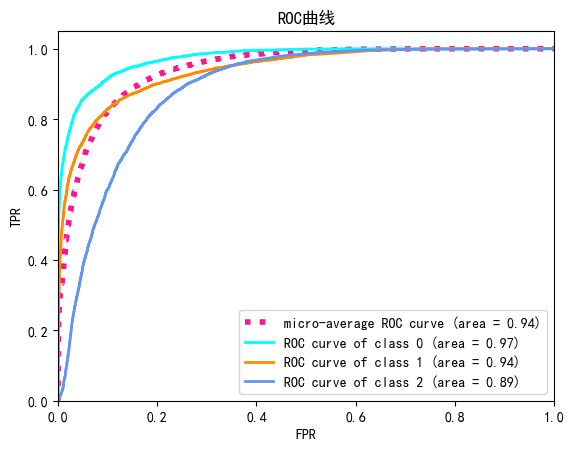

In [42]:

# ROC与AUC
import matplotlib.pyplot as plt

Y_valid = y_true_b
Y_pred = model_LR.predict()  # 用预测的概率值，不然ROC是折线的形式

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(nb_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_valid[:, i], Y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(Y_valid.ravel(), Y_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

lw = 2
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
  label='micro-average ROC curve (area = {0:0.2f})'
  ''.format(roc_auc["micro"]),
  color='deeppink', linestyle=':', linewidth=4)


colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])  # 几个类别就设置几个颜色
for i, color in zip(range(nb_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
    label='ROC curve of class {0} (area = {1:0.2f})'
    ''.format(i, roc_auc[i]))

# plt.plot([0, 1], [0, 1], 'k--', lw=lw)    # 斜着的分界线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC曲线')
plt.legend(loc="lower right")
# plt.savefig("../images/ROC/ROC_3分类.png")
plt.show()


# period_4

In [43]:
# 划分X和y
import numpy as np
# X = df_period_4[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point']]
X = df_period_4[['temperature_1', 'holiday', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2','MA2_sentiment_score','MA3_sentiment_score']]
# X = df_period_4[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2']]
# X = df_period_4[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score']]

y = np.array(df_period_4['sentiment_type']).astype('int')

from statsmodels.discrete.discrete_model import MNLogit
model_LR = MNLogit(y,X,missing='drop').fit()
model_LR.summary()	# 查看结果
model_LR.params		# 查看参数的系数


         Current function value: 0.446075
         Iterations: 35


D:\python\lib\site-packages\statsmodels\base\model.py:606: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
D:\python\lib\site-packages\statsmodels\discrete\discrete_model.py:4247: RuntimeWarning: invalid value encountered in sqrt
  bse = np.sqrt(np.diag(self.cov_params()))


,0,1
temperature_1,-13.157953,-5.717643
holiday,-1.171087,-0.417178
month,-0.188289,-0.094207
weather_point,-0.773237,-0.188473
previous_sentiment_score,-34.175381,-19.449373
previous_sentiment_score2,-11.837168,-6.409575
MA2_sentiment_score,44.871041,26.297939
MA3_sentiment_score,25.968304,15.395419


In [44]:
#  查看模型结果
model_LR.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                               Results: MNLogit
==============================================================================
Model:                  MNLogit              Pseudo R-squared:     0.564      
Dependent Variable:     y                    AIC:                  97306.6456 
Date:                   2023-04-15 22:26     BIC:                  97460.2362 
No. Observations:       109034               Log-Likelihood:       -48637.    
Df Model:               14                   LL-Null:              -1.1146e+05
Df Residuals:           109018               LLR p-value:          0.0000     
Converged:              0.0000               Scale:                1.0000     
No. Iterations:         35.0000                                               
------------------------------------------------------------------------------
          y = 0            Coef.   Std.Err.     t     P>|t|   [0.025   0.975] 
------------------------------------------------------------------------------
            temperature_1 -13.1580   0.1163 -113.1341 0.0000 -13.3859 -12.9300
                  holiday  -1.1711   0.0531  -22.0693 0.0000  -1.2751  -1.0671
                    month  -0.1883   0.0077  -24.3012 0.0000  -0.2035  -0.1731
            weather_point  -0.7732   0.1238   -6.2454 0.0000  -1.0159  -0.5306
 previous_sentiment_score -34.1754   0.2088 -163.6375 0.0000 -34.5847 -33.7660
previous_sentiment_score2 -11.8372      nan       nan    nan      nan      nan
      MA2_sentiment_score  44.8710      nan       nan    nan      nan      nan
      MA3_sentiment_score  25.9683      nan       nan    nan      nan      nan
------------------------------------------------------------------------------
          y = 1            Coef.   Std.Err.     t     P>|t|   [0.025   0.975] 
------------------------------------------------------------------------------
            temperature_1  -5.7176   0.0970  -58.9394 0.0000  -5.9078  -5.5275
                  holiday  -0.4172   0.0448   -9.3198 0.0000  -0.5049  -0.3294
                    month  -0.0942   0.0069  -13.6983 0.0000  -0.1077  -0.0807
            weather_point  -0.1885   0.1020   -1.8484 0.0645  -0.3883   0.0114
 previous_sentiment_score -19.4494   0.1806 -107.6718 0.0000 -19.8034 -19.0953
previous_sentiment_score2  -6.4096      nan       nan    nan      nan      nan
      MA2_sentiment_score  26.2979      nan       nan    nan      nan      nan
      MA3_sentiment_score  15.3954      nan       nan    nan      nan      nan
==============================================================================

"""

In [45]:

# 逻辑回归模型评价
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, f1_score, auc
from sklearn.preprocessing import label_binarize 
from itertools import cycle

# Precision Recall 和 F1
nb_classes = 3          # 设置分类数

y_pred = model_LR.predict()      # 自我预测，得到预测为各类的概率
y_pred_max = [np.argmax(y) for y in y_pred]   # 取出y中元素最大值所对应的索引
y_true = y

y_pred_b = label_binarize(y_pred_max, classes=[i for i in range(nb_classes)])    # binarize the output
y_true_b = label_binarize(y_true, classes=[i for i in range(nb_classes)])    # binarize the output

precision = precision_score(y_true_b, y_pred_b, average='micro')
recall = recall_score(y_true_b, y_pred_b, average='micro')
f1_score = f1_score(y_true_b, y_pred_b, average='micro')

print("Precision_score:",precision)
print("Recall_score:",recall)
print("F1_score:",f1_score)



Precision_score: 0.8090962452079168
Recall_score: 0.8090962452079168
F1_score: 0.8090962452079167


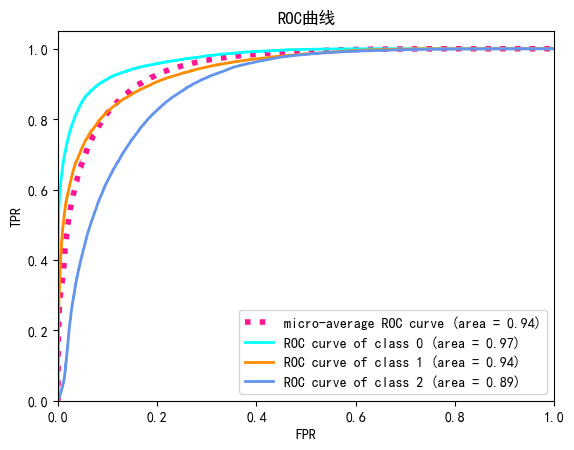

In [46]:

# ROC与AUC
import matplotlib.pyplot as plt

Y_valid = y_true_b
Y_pred = model_LR.predict()  # 用预测的概率值，不然ROC是折线的形式

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(nb_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_valid[:, i], Y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(Y_valid.ravel(), Y_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

lw = 2
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
  label='micro-average ROC curve (area = {0:0.2f})'
  ''.format(roc_auc["micro"]),
  color='deeppink', linestyle=':', linewidth=4)


colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])  # 几个类别就设置几个颜色
for i, color in zip(range(nb_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
    label='ROC curve of class {0} (area = {1:0.2f})'
    ''.format(i, roc_auc[i]))

# plt.plot([0, 1], [0, 1], 'k--', lw=lw)    # 斜着的分界线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC曲线')
plt.legend(loc="lower right")
# plt.savefig("../images/ROC/ROC_3分类.png")
plt.show()


# period_5

In [47]:
# 划分X和y
import numpy as np
# X = df_period_5[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point']]
X = df_period_5[['temperature_1', 'holiday', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2','MA2_sentiment_score','MA3_sentiment_score']]
# X = df_period_5[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2']]
# X = df_period_5[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score']]

y = np.array(df_period_5['sentiment_type']).astype('int')

from statsmodels.discrete.discrete_model import MNLogit
model_LR = MNLogit(y,X,missing='drop').fit()
model_LR.summary()	# 查看结果
model_LR.params		# 查看参数的系数


         Current function value: 0.314469
         Iterations: 35


D:\python\lib\site-packages\statsmodels\base\model.py:606: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)


,0,1
temperature_1,-11.543680,-4.217530
holiday,0.400394,0.167987
month,-1.325575,-0.500258
weather_point,-2.032599,-0.630134
previous_sentiment_score,-43.530867,-22.536742
previous_sentiment_score2,-12.828200,-6.660624
MA2_sentiment_score,61.536768,32.106136
MA3_sentiment_score,36.748445,19.183903


In [48]:
#  查看模型结果
model_LR.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                    Results: MNLogit
========================================================================================
Model:                      MNLogit                 Pseudo R-squared:        0.692      
Dependent Variable:         y                       AIC:                     70350.4876 
Date:                       2023-04-15 22:27        BIC:                     70504.4798 
No. Observations:           111805                  Log-Likelihood:          -35159.    
Df Model:                   14                      LL-Null:                 -1.1414e+05
Df Residuals:               111789                  LLR p-value:             0.0000     
Converged:                  0.0000                  Scale:                   1.0000     
No. Iterations:             35.0000                                                     
----------------------------------------------------------------------------------------
          y = 0            Coef.     Std.Err.      t     P>|t|     [0.025       0.975]  
----------------------------------------------------------------------------------------
            temperature_1 -11.5437      0.1350  -85.5047 0.0000     -11.8083    -11.2791
                  holiday   0.4004      0.0540    7.4168 0.0000       0.2946      0.5062
                    month  -1.3256      0.0119 -111.7815 0.0000      -1.3488     -1.3023
            weather_point  -2.0326      0.1981  -10.2582 0.0000      -2.4210     -1.6442
 previous_sentiment_score -43.5309      0.2545 -171.0608 0.0000     -44.0296    -43.0321
previous_sentiment_score2 -12.8282 152524.8078   -0.0001 0.9999 -298955.9583 298930.3019
      MA2_sentiment_score  61.5368 305510.7847    0.0002 0.9998 -598728.5982 598851.6717
      MA3_sentiment_score  36.7484 460394.6891    0.0001 0.9999 -902320.2609 902393.7578
----------------------------------------------------------------------------------------
          y = 1            Coef.     Std.Err.      t     P>|t|     [0.025       0.975]  
----------------------------------------------------------------------------------------
            temperature_1  -4.2175      0.1041  -40.5178 0.0000      -4.4215     -4.0135
                  holiday   0.1680      0.0430    3.9090 0.0001       0.0838      0.2522
                    month  -0.5003      0.0089  -56.2170 0.0000      -0.5177     -0.4828
            weather_point  -0.6301      0.1568   -4.0192 0.0001      -0.9374     -0.3229
 previous_sentiment_score -22.5367      0.2027 -111.1970 0.0000     -22.9340    -22.1395
previous_sentiment_score2  -6.6606 129567.6776   -0.0001 1.0000 -253954.6422 253941.3210
      MA2_sentiment_score  32.1061 259135.3552    0.0001 0.9999 -507863.8571 507928.0694
      MA3_sentiment_score  19.1839 388703.0327    0.0000 1.0000 -761824.7609 761863.1287
========================================================================================

"""

In [49]:
# 逻辑回归模型评价
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, f1_score, auc
from sklearn.preprocessing import label_binarize 
from itertools import cycle

# Precision Recall 和 F1
nb_classes = 3          # 设置分类数

y_pred = model_LR.predict()      # 自我预测，得到预测为各类的概率
y_pred_max = [np.argmax(y) for y in y_pred]   # 取出y中元素最大值所对应的索引
y_true = y

y_pred_b = label_binarize(y_pred_max, classes=[i for i in range(nb_classes)])    # binarize the output
y_true_b = label_binarize(y_true, classes=[i for i in range(nb_classes)])    # binarize the output

precision = precision_score(y_true_b, y_pred_b, average='micro')
recall = recall_score(y_true_b, y_pred_b, average='micro')
f1_score = f1_score(y_true_b, y_pred_b, average='micro')

print("Precision_score:",precision)
print("Recall_score:",recall)
print("F1_score:",f1_score)



Precision_score: 0.8657305129466482
Recall_score: 0.8657305129466482
F1_score: 0.8657305129466482


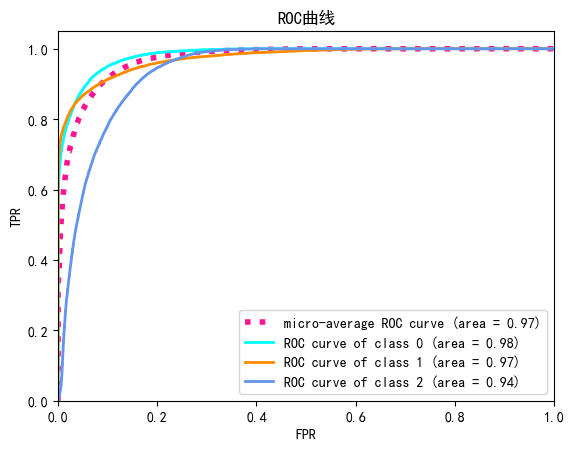

In [50]:
# ROC与AUC
import matplotlib.pyplot as plt

Y_valid = y_true_b
Y_pred = model_LR.predict()  # 用预测的概率值，不然ROC是折线的形式

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(nb_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_valid[:, i], Y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(Y_valid.ravel(), Y_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

lw = 2
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
  label='micro-average ROC curve (area = {0:0.2f})'
  ''.format(roc_auc["micro"]),
  color='deeppink', linestyle=':', linewidth=4)


colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])  # 几个类别就设置几个颜色
for i, color in zip(range(nb_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
    label='ROC curve of class {0} (area = {1:0.2f})'
    ''.format(i, roc_auc[i]))

# plt.plot([0, 1], [0, 1], 'k--', lw=lw)    # 斜着的分界线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC曲线')
plt.legend(loc="lower right")
# plt.savefig("../images/ROC/ROC_3分类.png")
plt.show()
